# Sensor Degradation Pipeline

This notebook simulates the degradation of a remote sensing imagery to lower-quality sensor characteristics, producing synthetic training data for resolution-agnostic boat detection models.

Each tile is transformed by a randomised combination of three degradation operations drawn from `tile_mixture_assignments.csv`:

| Symbol | Operation | What it models |
|--------|-----------|----------------|
| **B** | Gaussian PSF blur | Optical MTF of a lower-resolution sensor |
| **D** | Average-pool downsample | Satellite resolution (GSD) |
| **N** | Poisson noise | Shot noise at a target SNR (dB) |

The step order (e.g. `BDN`, `NDB`, …) is part of the mixture and is applied as listed.

---
## 1. Imports & Core Functions

All primitive operations live here. Each function is stateless and operates on a `(C, H, W)` NumPy array, making them freely composable in any order.

- **`blur`** - applies a Gaussian PSF whose σ is scaled by the GSD ratio so the spatial frequency content matches the target sensor's MTF.
- **`noise`** - adds Poisson noise calibrated to a given SNR target in dB.
- **`downsample`** - integer average-pool at the nearest integer GSD scale factor.
- **`extract_tile`** - reads a geographic bounding-box crop from a GeoTIFF via rasterio.
- **`convert_to_uint8`** - normalises to 8-bit using a fixed global ceiling for display.
- **`apply_transform`** - orchestrates the above operations in the order specified by a mixture record.

## Note pour moi-même :


**2 problèmes pour notre reduction :**


* 1 - Le downsampling :
  * Actuellement une moyenne par entier (donne du 0.6m/px) -> Pas 0.5 !
  * L'interpollation bicubic ou lancoz ne sont physiquement pas justifiables elles cherchent surtout à donner un certains aspect visuel à l'image mais ne correspondent à aucune réalitées physiques.
  * Le capteur CCD est un carré physique. Il capte toute la lumière qui tombe dans ce carré géométrique de manière uniforme. Ce qui est la définition d'une moyenne arithmétique. (on peut donc bien faire une moyenne à la place d'une interpollation)
  * Pour remplacer ma moyenne par entier on Gemini propose : 


```L'interpolation INTER_AREA est l'équivalent parfait de ton "Average Pooling", mais elle est capable de calculer mathématiquement l'aire de recouvrement si un pixel cible tombe "à cheval" sur un pixel source (ce qui gère ton ratio de 1.667).```
* 2 - Le flou :
  * Pour être rigoureux il faudrait avoir plusieurs type de flou (regarder les 4 types de flous de Real-ESRGAN (https://arxiv.org/pdf/2107.10833) )


Ce que chaque type de flou simule dans la réalité :

* **Le flou Gaussien Isotrope (Un rond parfait) :** Il simule la diffraction optique pure de la lentille (la tache d'Airy) et la dispersion atmosphérique (la lumière déviée par les particules dans l'air de manière uniforme).
* **Le flou Gaussien Anisotrope (Une ellipse orientée) :** Le satellite file à environ 7 km/s au-dessus de la Terre. S'il y a de très légères vibrations de la plateforme (jitter), ou si le temps d'intégration du capteur n'est pas parfaitement synchronisé avec le défilement du sol (*smear along-track*), le flou ne sera pas rond, il sera étiré dans une direction précise. C'est le rôle du flou anisotrope.
* **Le filtre Sinc (L'effet de "ringing" ou d'écho) :** Ce n'est pas un flou optique, c'est un flou numérique. Les images Pléiades (produits L1C) sont orthorectifiées, rééchantillonnées géométriquement et compressées (ex: JPEG2000). Ces algorithmes mathématiques créent de petits "échos" ou "rebonds" (ringing) autour des bords très contrastés (comme le toit d'un bateau blanc sur l'eau noire). 


In [ ]:
import math
import numpy as np
from scipy.ndimage import gaussian_filter

import rasterio
from rasterio.windows import Window

# pip install git+https://github.com/JulioContrerasH/satharmony
from satharmony import MSSEmulator, PipelineConfig



def blur(image: np.ndarray, psf_sigma: float, source_gsd: float, target_gsd: float) -> np.ndarray:
    """Apply Gaussian PSF blur scaled to the GSD ratio."""
    scale_factor = target_gsd / source_gsd
    sigma_pixels = psf_sigma * scale_factor
    blurred = np.empty_like(image, dtype=np.float64)
    for c in range(image.shape[0]):
        blurred[c] = gaussian_filter(image[c].astype(np.float64), sigma=sigma_pixels)
    return blurred
 
 # https://camera.hamamatsu.com/us/en/learn/technical_information/thechnical_guide/photon_shot_noise.html
def noise(image: np.ndarray, snr_db: float) -> np.ndarray:
    """
    Add physically-consistent Poisson (shot) noise at a target global SNR in dB.
    """
    image64 = image.astype(np.float64)

    # Conversion de l'amplitude en décibels (dB)
    snr_linear = 10 ** (snr_db / 20)

    # En physique du signal, l'énergie ou la "puissance" d'un signal numérique est définie comme la moyenne des carrés de ses valeurs. 
    signal_power = np.mean(image64 ** 2)

    if signal_power <= 0:
        return image
    
    # Déduire l'écart-type du bruit : on divise la racine de la puissance par le SNR cible pour obtenir l'écart-type du bruit ($\sigma$) que l'on doit injecter.
    noise_std = np.sqrt(signal_power) / snr_linear

    mean_intensity = np.mean(image64)
    scale = mean_intensity / (noise_std ** 2 + 1e-10)
    noisy = np.random.poisson(
        np.clip(image64 * scale, 0, None)
    ).astype(np.float64)
    return noisy / scale
 
 
def downsample(image: np.ndarray, source_gsd: float, target_gsd: float) -> np.ndarray:
    """Average-pool downsample by the GSD ratio (integer scale)."""
    scale = int(round(target_gsd / source_gsd))
    if scale == 1:
        return image
    C, H, W = image.shape
    new_H = H // scale
    new_W = W // scale
    cropped = image[:, : new_H * scale, : new_W * scale]
    return cropped.reshape(C, new_H, scale, new_W, scale).mean(axis=(2, 4))


def extract_tile(source_image: str, min_x: float, max_x: float, 
                 min_y: float, max_y: float) -> tuple[np.ndarray, any]:
    """Extract a tile from the source image using rasterio."""
    with rasterio.open(source_image) as src:
        window = rasterio.windows.from_bounds(min_x, min_y, max_x, max_y, src.transform)
        tile = src.read(window=window)
        transform = src.window_transform(window)
    return tile, transform

def convert_to_uint8(image: np.ndarray, global_max: float = None) -> np.ndarray:
    """
    Convert image to uint8 using a global maximum.
    If global_max is None, it defaults based on dtype (255 for uint8, 2500 for others).
    """
    if global_max is None:
        if image.dtype == np.uint8:
            global_max = 255.0
        else:
            # Heuristic: if max value is low, it's likely uint8 data converted to float
            global_max = 255.0 if np.max(image) <= 255.0 else 2500.0
        
    # Clip values to ensure they stay within the [0, global_max] bounds
    clipped = np.clip(image, 0, global_max)
    
    # Scale to [0, 255] based on the fixed range
    scaled = (clipped / global_max) * 255.0
    
    return scaled.astype(np.uint8)

def apply_transform(source_image: str, transform_params: dict) -> tuple[np.ndarray, any]:
    """
    Apply a sequence of degradation operations (B / D / N) in the specified order.

    Parameters for B and N are adjusted on-the-fly depending on whether D has
    already been applied, so the *effective* PSF and SNR at the output are
    always consistent with the requested values regardless of step order:

    B (blur)
      • Before D: image is at source GSD → sigma is scaled up by (target/source)
        so it covers the right number of source pixels.
      • After  D: image is already at target GSD → sigma is applied as-is
        (scale factor = 1).

    N (noise)
      • After  D: add Poisson noise directly at the target SNR.
      • Before D: average-pooling by integer factor k reduces noise std by k,
        boosting SNR by 20·log10(k) dB. To still land at snr_db after downsampling,
        the pre-D noise is added at snr_db - 20·log10(k) dB.
    """
    min_x = transform_params.get("min_x")
    max_x = transform_params.get("max_x")
    min_y = transform_params.get("min_y")
    max_y = transform_params.get("max_y")
    psf_sigma = transform_params.get("psf_sigma")
    snr_db = transform_params.get("snr_db")
    order = transform_params.get("order")
    source_gsd = transform_params.get("source_gsd")
    target_gsd = transform_params.get("target_gsd")

    # integer downsample factor - used to compensate noise added before D
    ds_factor = int(round(target_gsd / source_gsd))

    # extract tile using rasterio
    tile, geometadata = extract_tile(source_image, min_x, max_x, min_y, max_y)

    downsampled = False  # tracks whether D has been applied yet

    for op in order:
        if op == "B":
            if downsampled:
                # Image is at target GSD: apply sigma directly (scale_factor = 1)
                tile = blur(tile, psf_sigma, target_gsd, target_gsd)
            else:
                # Image is at source GSD: blur() will scale sigma up by target/source
                tile = blur(tile, psf_sigma, source_gsd, target_gsd)
        elif op == "N":
            if downsampled:
                # Image is at target GSD: add noise at the requested SNR directly
                tile = noise(tile, snr_db)
            else:
                # Image is at source GSD: subsequent average-pooling by ds_factor
                # 
                pre_snr_db = snr_db - 20 * math.log10(ds_factor)
                tile = noise(tile, pre_snr_db)
        elif op == "D":
            tile = downsample(tile, source_gsd, target_gsd)
            downsampled = True
        else:
            raise ValueError(f"Unknown operation '{op}' in order '{order}'")

    return tile, geometadata



# ---- Physics informed -----

_NEO_DN_MAX = 4095.0   # 12-bit ADC ceiling - NEO-UG Table 4
_NEO_MS_GSD = 0.3      # Neo PMS GSD - NEO-UG Table 4
_PHR_MS_GSD = 0.5      # PHR PMS GSD - PHR-UG §2.2
_GSD_RATIO  = _PHR_MS_GSD / _NEO_MS_GSD  # ≈ 1.667

def config_neo_to_phr() -> PipelineConfig:
    """
    Build the physics-informed Neo → PHR emulation config.
    """
    config = PipelineConfig()

    # Spectral - select RGB bands (Neo order: R=0, G=1, B=2) and adjust SRFs
    # PHR bands are wider than Neo's (e.g. PHR Blue 430–550 nm vs Neo 450–520 nm)
    config.spectral.enabled           = True
    config.spectral.s2_bands          = [0, 1, 2]
    config.spectral.srf_adjustment    = True
    config.spectral.srf_noise_std.min = 0.005   # ≤2% residual after SRF correction
    config.spectral.srf_noise_std.max = 0.020

    # Spatial - PHR PSF from MTF@Nyquist=0.15 → σ≈0.620 px (PHR-UG §2.3)
    config.spatial.enabled          = True
    config.spatial.input_gsd        = _NEO_MS_GSD
    config.spatial.target_gsd.min   = _PHR_MS_GSD
    config.spatial.target_gsd.max   = _PHR_MS_GSD
    config.spatial.psf_sigma.min    = 0.60
    config.spatial.psf_sigma.max    = 0.64

    # Radiometric - 12-bit, no sqrt compression (PHR-UG §2.4.1)
    config.radiometric.enabled                  = True
    config.radiometric.quantization_bits        = 12
    config.radiometric.sqrt_compression         = False
    config.radiometric.sqrt_bands               = []
    config.radiometric.saturation_threshold.min = 0.97
    config.radiometric.saturation_threshold.max = 1.00
    config.radiometric.reflectance_boost.min    = 0.98
    config.radiometric.reflectance_boost.max    = 1.02
    config.radiometric.reflectance_boost_prob   = 0.3

    # Noise - Poisson shot noise, PHR RGB SNR ~43.5 dB (PHR-UG §2.3)
    config.random_noise.enabled            = True
    config.random_noise.probability        = 1.0
    config.random_noise.noise_type         = "poisson"
    config.random_noise.snr_db.min         = 42
    config.random_noise.snr_db.max         = 44
    config.random_noise.poisson_weight.min = 0.5
    config.random_noise.poisson_weight.max = 0.7

    # Artifacts not present in standard PHR ortho products
    config.striping.enabled       = False
    config.memory_effect.enabled  = False
    config.coherent_noise.enabled = False
    config.scan_artifacts.enabled = False

    return config


def apply_physics_informed_transform(
    source_image: str,
    transform_params: dict,
) -> tuple[np.ndarray, any]:
    """
    Extract a tile and apply the physics-informed Neo → PHR emulation.
    """
    min_x = transform_params["min_x"]
    max_x = transform_params["max_x"]
    min_y = transform_params["min_y"]
    max_y = transform_params["max_y"]

    # 1. Extract the tile (same helper as the existing notebook cell)
    tile, geometadata = extract_tile(source_image, min_x, max_x, min_y, max_y)

    # 2. Select first 3 bands (Neo RGB order: R=0, G=1, B=2) and normalise to [0, 1]
    rgb = tile[:3].astype(np.float32) / _NEO_DN_MAX

    # 3. Build emulator (config is lightweight - safe to instantiate per tile)
    emulator = MSSEmulator(config_neo_to_phr())

    # 4. Run emulation - input/output shape: (3, H, W) float32 in [0, 1]
    phr_norm = emulator(rgb)

    # 5. Re-quantise to 12-bit PHR DN range
    phr_dn = (phr_norm * _NEO_DN_MAX).clip(0, _NEO_DN_MAX).astype(np.uint16)

    return phr_dn, geometadata




---
## 2.Synthetic Degradation 


Loaded 21 records - visualising 1 sample(s).
image_id           IMG_PNEO3_STD_202304300656161_MS-FS_ORT_PWOI_0...
tile_id                                                   12288_5120
min_x                                                       313554.0
max_x                                                       313861.2
min_y                                                      8642714.4
max_y                                                      8643021.6
tile_size_px                                                    1024
length_x_meters                                                307.2
length_y_meters                                                307.2
native_crs                                                EPSG:32739
GSD_input                                                        0.3
GSD_output                                                       0.5
Transform_id                                                      15
Order                                                     

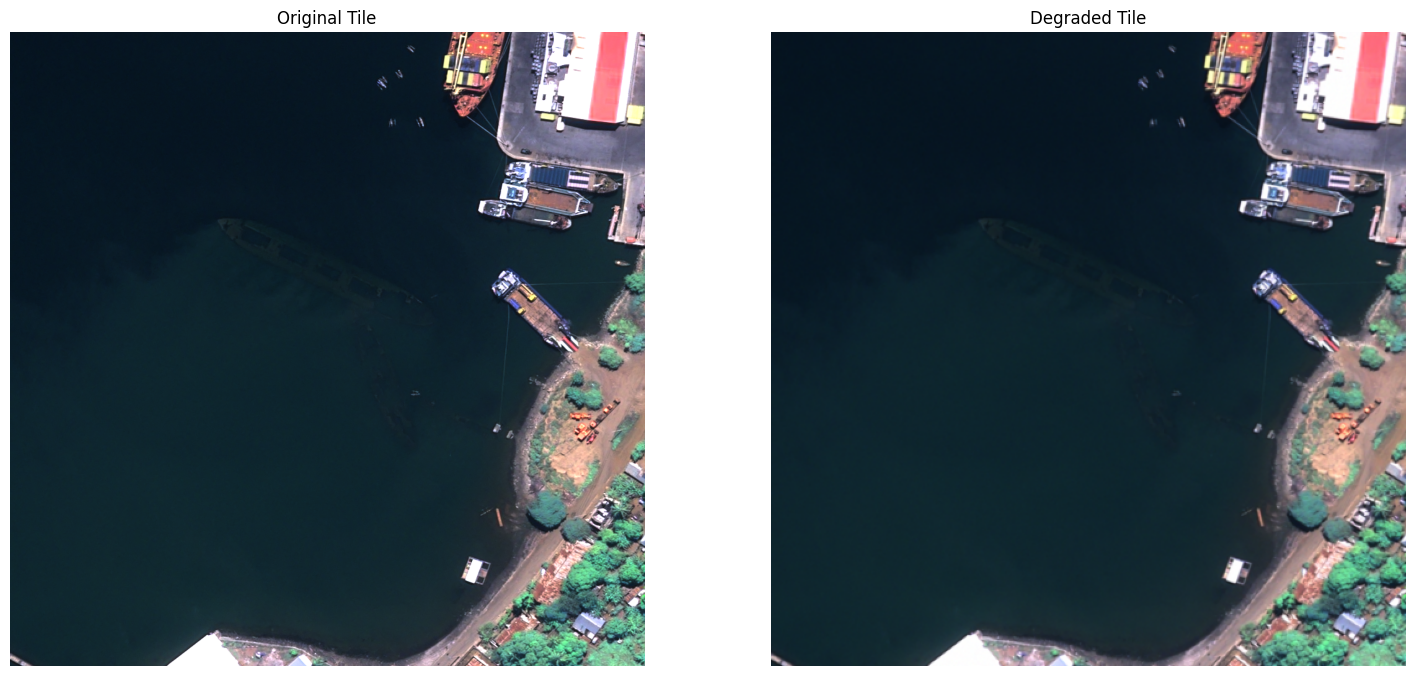

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import random

source_dir = "/home/thomas/Documents/code/pleiades-boat-detection/data/raw"
source_csv = "/home/thomas/Documents/code/pleiades-boat-detection/tile_mixture_assignments.csv"
df = pd.read_csv(source_csv)

# -- Sampling options (uncomment as needed) --
# df = df[df["Transform_id"] == 2]   # restrict to a specific mixture id
# df = df[df["Order"] == "BDN"]       # restrict to a specific step order
# 12288_5120
# image_id           IMG_PNEO3_STD_202304300656161_MS-FS_ORT_PWOI_0...
df = df[df["tile_id"] == "12288_5120"]       



sample_rows = df.sample(n=1, random_state=random.randint(0, 10000))

print(f"Loaded {len(df)} records - visualising {len(sample_rows)} sample(s).")

for _, row in sample_rows.iterrows():
    source_image = f"{source_dir}/{row['image_id']}"
    transform_params = {
        "min_x": row["min_x"],
        "max_x": row["max_x"],
        "min_y": row["min_y"],
        "max_y": row["max_y"],
        "psf_sigma": row["PSF"],
        "snr_db": row["SNR (dB)"],
        "order": row["Order"],
        "source_gsd": row["GSD_input"],
        "target_gsd": row["GSD_output"]
    }

    degraded_tile, geometadata = apply_transform(source_image, transform_params)
    print(row)
    original_tile, _ = extract_tile(source_image, transform_params["min_x"], transform_params["max_x"], transform_params["min_y"], transform_params["max_y"])

    # Use the same global_max for both to ensure consistent visualization
    g_max = 255.0 if original_tile.dtype == np.uint8 else 2500.0

    plt.figure(figsize=(18, 9))
    plt.subplot(1, 2, 1)
    plt.imshow(convert_to_uint8(original_tile[:3], global_max=g_max).transpose(1, 2, 0))
    plt.title("Original Tile")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(convert_to_uint8(degraded_tile[:3], global_max=g_max).transpose(1, 2, 0))
    plt.title("Degraded Tile")
    plt.axis("off")
    plt.show()


---
## 3. Physics-Informed Transform (Pléiades Neo → PHR Emulation)

The section above applies **parametric** degradations (blur, downsample, noise) with values drawn from `tile_mixture_assignments.csv`. This section instead uses **`satharmony`** - a physics-grounded pipeline that jointly models spectral response functions, the optical PSF, 12-bit radiometric quantisation, and Poisson shot noise, all calibrated to public sensor specifications.


> **Requires:** `pip install git+https://github.com/JulioContrerasH/satharmony`

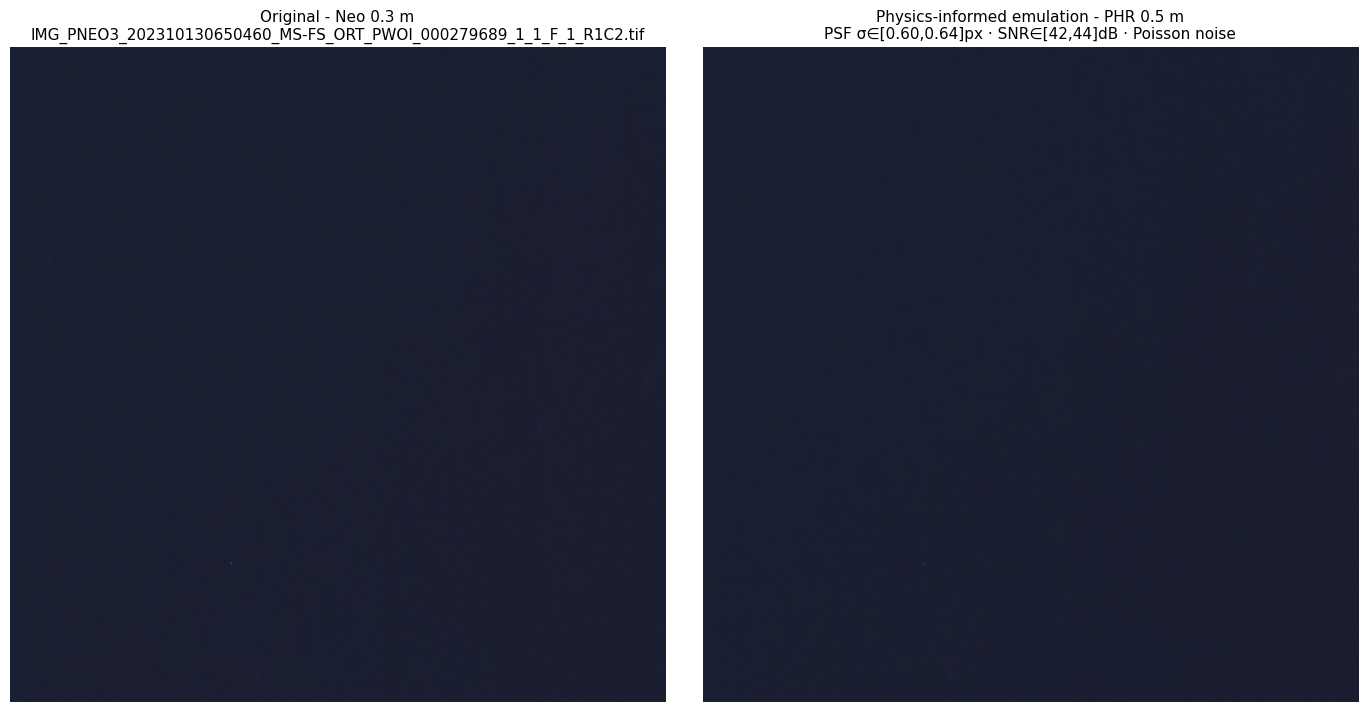

Original shape : (4, 1024, 1024)  dtype: uint8
Emulated shape : (3, 512, 512)  dtype: uint16


In [3]:

sample_rows = df.sample(n=1, random_state=random.randint(0, 10000))

for _, row in sample_rows.iterrows():
    source_image = f"{source_dir}/{row['image_id']}"
    transform_params = {
        "min_x": row["min_x"],
        "max_x": row["max_x"],
        "min_y": row["min_y"],
        "max_y": row["max_y"],
    }

    # Original tile
    original_tile, _ = extract_tile(
        source_image,
        transform_params["min_x"], transform_params["max_x"],
        transform_params["min_y"], transform_params["max_y"],
    )

    # Physics-informed emulated tile
    physics_tile, _ = apply_physics_informed_transform(source_image, transform_params)

    # Use a more sensible ceiling for visualization (consistent with Section 2)
    g_max = 255.0 if original_tile.dtype == np.uint8 else 2500.0

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(convert_to_uint8(original_tile[:3], global_max=g_max).transpose(1, 2, 0))
    axes[0].set_title(f"Original - Neo 0.3 m\n{row['image_id']}", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(convert_to_uint8(physics_tile[:3], global_max=g_max).transpose(1, 2, 0))
    axes[1].set_title(
        f"Physics-informed emulation - PHR 0.5 m\n"
        f"PSF σ∈[0.60,0.64]px · SNR∈[42,44]dB · Poisson noise",
        fontsize=11,
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Original shape : {original_tile.shape}  dtype: {original_tile.dtype}")
    print(f"Emulated shape : {physics_tile.shape}  dtype: {physics_tile.dtype}")



---
## 4. Side-by-Side Comparison : Original · Parametric · Physics-Informed

All three representations of the same tile are displayed on a shared 12-bit DN scale (`global_max = 4095`) so any brightness or sharpness differences are real and not an artefact of normalisation.

| Panel | Source | GSD | What varies |
|-------|--------|-----|-------------|
| **Original** | Raw Neo GeoTIFF | 0.3 m | - |
| **Parametric** | `apply_transform` with CSV mixture | 0.5 m | PSF σ, SNR, step order from CSV row |
| **Physics-informed** | `apply_physics_informed_transform` | 0.5 m | PSF σ ∈ [0.60, 0.64], SNR ∈ [42, 44] dB, SRF + radiometry |

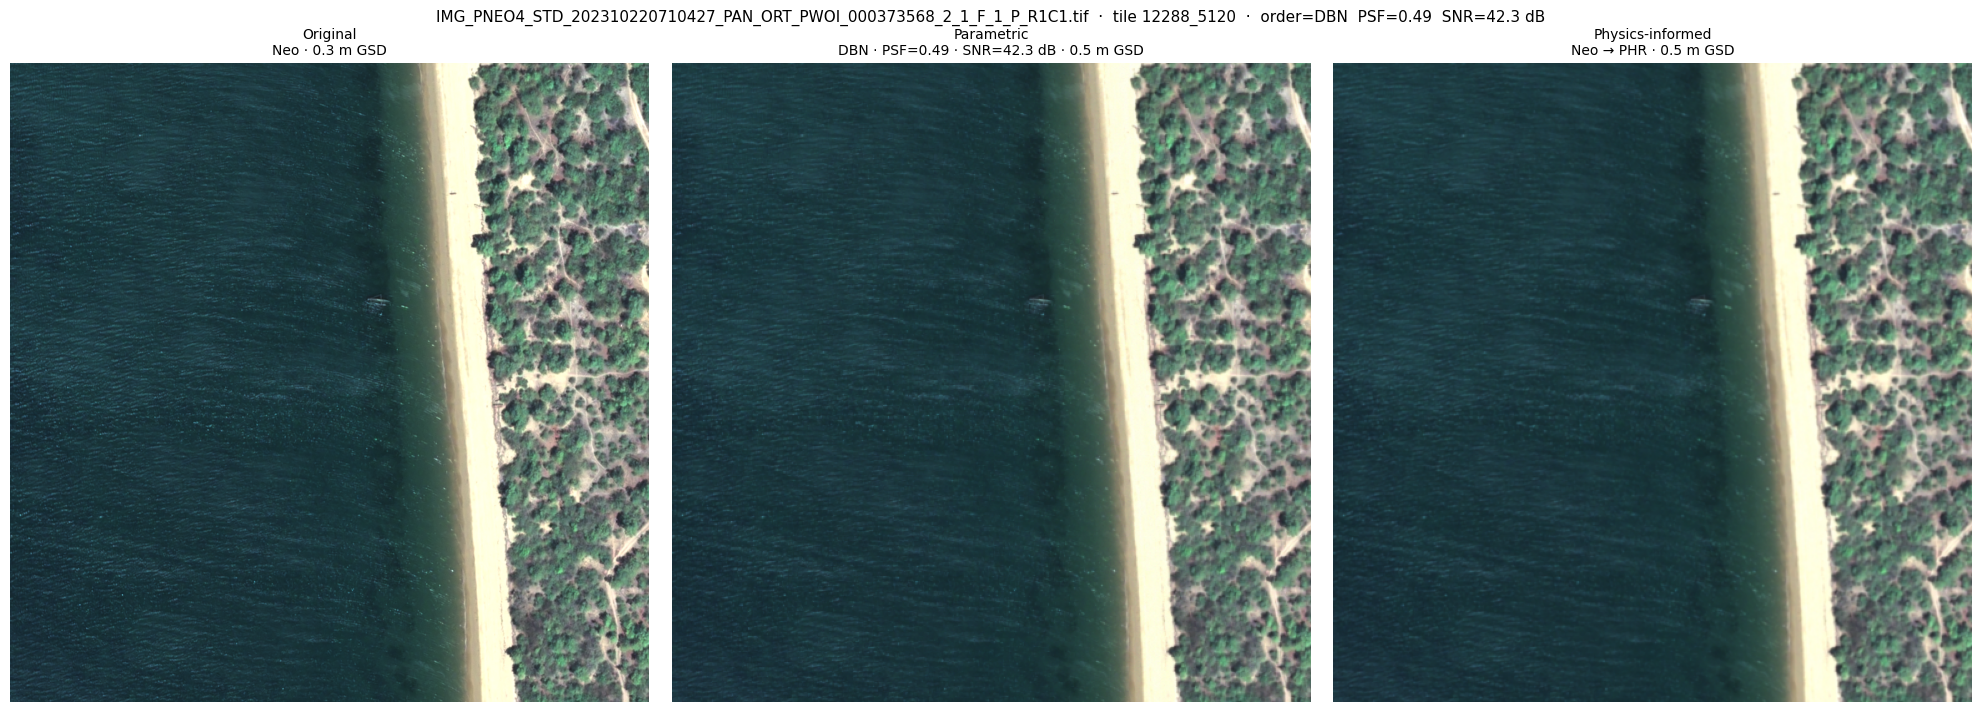

  original   (4, 1024, 1024)  uint8
  parametric (4, 512, 512)  float64
  physics    (3, 512, 512)  uint16


In [4]:
sample_rows = df.sample(n=1, random_state=random.randint(0, 10000))

for _, row in sample_rows.iterrows():
    source_image = f"{source_dir}/{row['image_id']}"

    # ── 1. Original ──────────────────────────────────────────────────────────
    original_tile, _ = extract_tile(
        source_image,
        row["min_x"], row["max_x"],
        row["min_y"], row["max_y"],
    )

    # ── 2. Parametric (from CSV mixture) ─────────────────────────────────────
    parametric_tile, _ = apply_transform(source_image, {
        "min_x":      row["min_x"],
        "max_x":      row["max_x"],
        "min_y":      row["min_y"],
        "max_y":      row["max_y"],
        "psf_sigma":  row["PSF"],
        "snr_db":     row["SNR (dB)"],
        "order":      row["Order"],
        "source_gsd": row["GSD_input"],
        "target_gsd": row["GSD_output"],
    })

    # ── 3. Physics-informed (satharmony Neo → PHR) ───────────────────────────
    physics_tile, _ = apply_physics_informed_transform(source_image, {
        "min_x": row["min_x"],
        "max_x": row["max_x"],
        "min_y": row["min_y"],
        "max_y": row["max_y"],
    })

    # ── Display ──────────────────────────────────────────────────────────────
    # Use a more sensible ceiling for visualization (consistent with Section 2)
    g_max = 255.0 if original_tile.dtype == np.uint8 else 2500.0

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(
        f"{row['image_id']}  ·  tile {row['tile_id']}  ·  "
        f"order={row['Order']}  PSF={row['PSF']:.2f}  SNR={row['SNR (dB)']:.1f} dB",
        fontsize=11, y=1.01,
    )

    axes[0].imshow(convert_to_uint8(original_tile[:3],   global_max=g_max).transpose(1, 2, 0))
    axes[0].set_title(f"Original\nNeo · {row['GSD_input']} m GSD", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(convert_to_uint8(parametric_tile[:3], global_max=g_max).transpose(1, 2, 0))
    axes[1].set_title(
        f"Parametric\n{row['Order']} · PSF={row['PSF']:.2f} · "
        f"SNR={row['SNR (dB)']:.1f} dB · {row['GSD_output']} m GSD",
        fontsize=10,
    )
    axes[1].axis("off")

    axes[2].imshow(convert_to_uint8(physics_tile[:3],    global_max=g_max).transpose(1, 2, 0))
    axes[2].set_title(
        f"Physics-informed\nNeo → PHR · {_PHR_MS_GSD} m GSD",
        fontsize=10,
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print(
        f"  original   {original_tile.shape}  {original_tile.dtype}\n"
        f"  parametric {parametric_tile.shape}  {parametric_tile.dtype}\n"
        f"  physics    {physics_tile.shape}  {physics_tile.dtype}"
    )
